<a href="https://colab.research.google.com/github/astrajoan/CSCE-636/blob/main/Homework2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# K-fold validation

Boston housing dataset

In [ ]:
import keras
from keras.datasets import boston_housing

(train_data, train_targets), (test_data, test_targets) =  boston_housing.load_data()

Normalize data

In [ ]:
mean = train_data.mean(axis=0)
train_data -= mean # Zero mean
std = train_data.std(axis=0)
train_data /= std # Variance 1

test_data -= mean
test_data /= std

Build model

In [ ]:
from keras import models
from keras import layers

def build_model():
    # Because we will need to instantiate
    # the same model multiple times,
    # we use a function to construct it.
    model = models.Sequential()
    model.add(layers.Dense(64, activation='relu',
                           input_shape=(train_data.shape[1],)))
    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.Dense(1))
    model.compile(optimizer='rmsprop', loss='mse', metrics=['mae'])
    return model

K-fold validation

In [ ]:
import numpy as np

k = 4
num_val_samples = len(train_data) // k
num_epochs = 100
all_scores = []
for i in range(k):
    print('processing fold #', i)
    # Prepare the validation data: data from partition # k
    val_data = train_data[i * num_val_samples: (i + 1) * num_val_samples]
    val_targets = train_targets[i * num_val_samples: (i + 1) * num_val_samples]

    # Prepare the training data: data from all other partitions
    partial_train_data = np.concatenate(
        [train_data[:i * num_val_samples],
         train_data[(i + 1) * num_val_samples:]],
        axis=0)
    partial_train_targets = np.concatenate(
        [train_targets[:i * num_val_samples],
         train_targets[(i + 1) * num_val_samples:]],
        axis=0)

    # Build the Keras model (already compiled)
    model = build_model()
    # Train the model (in silent mode, verbose=0)
    model.fit(partial_train_data, partial_train_targets,
              epochs=num_epochs, batch_size=1, verbose=0)
    # Evaluate the model on the validation data
    val_mse, val_mae = model.evaluate(val_data, val_targets, verbose=0)
    all_scores.append(val_mae)

processing fold # 0
processing fold # 1
processing fold # 2
processing fold # 3


In [ ]:
from keras import backend as K

# Some memory clean-up
K.clear_session()

num_epochs = 500
all_mae_histories = []
for i in range(k):
    print('processing fold #', i)
    # Prepare the validation data: data from partition # k
    val_data = train_data[i * num_val_samples: (i + 1) * num_val_samples]
    val_targets = train_targets[i * num_val_samples: (i + 1) * num_val_samples]

    # Prepare the training data: data from all other partitions
    partial_train_data = np.concatenate(
        [train_data[:i * num_val_samples],
         train_data[(i + 1) * num_val_samples:]],
        axis=0)
    partial_train_targets = np.concatenate(
        [train_targets[:i * num_val_samples],
         train_targets[(i + 1) * num_val_samples:]],
        axis=0)

    # Build the Keras model (already compiled)
    model = build_model()
    # Train the model (in silent mode, verbose=0)
    history = model.fit(partial_train_data, partial_train_targets,
                        validation_data=(val_data, val_targets),
                        epochs=num_epochs, batch_size=1, verbose=0)
    mae_history = history.history['val_mae']
    all_mae_histories.append(mae_history)

average_mae_history = [
    np.mean([x[i] for x in all_mae_histories]) for i in range(num_epochs)]

processing fold # 0
processing fold # 1
processing fold # 2
processing fold # 3


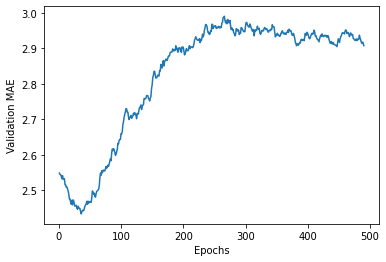

In [ ]:
import matplotlib.pyplot as plt

def smooth_curve(points, factor=0.9):
  smoothed_points = []
  for point in points:
    if smoothed_points:
      previous = smoothed_points[-1]
      smoothed_points.append(previous * factor + point * (1 - factor))
    else:
      smoothed_points.append(point)
  return smoothed_points

smooth_mae_history = smooth_curve(average_mae_history[10:])

plt.plot(range(1, len(smooth_mae_history) + 1), smooth_mae_history)
plt.xlabel('Epochs')
plt.ylabel('Validation MAE')
plt.show()

# Underfitting and overfitting

IMDB dataset

In [ ]:
from keras.datasets import imdb

(train_data, train_labels), (test_data, test_labels) = imdb.load_data(num_words=10000)

def vectorize_sequences(sequences, dimension=10000):
    # Create an all-zero matrix of shape (len(sequences), dimension)
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        results[i, sequence] = 1.  # set specific indices of results[i] to 1s
    return results

# Our vectorized training data
x_train_data = vectorize_sequences(train_data)
# Our vectorized test data
x_test = vectorize_sequences(test_data)
# Our vectorized labels
y_train_data = np.asarray(train_labels).astype('float32')
y_test = np.asarray(test_labels).astype('float32')

<string>:6: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray
/usr/local/lib/python3.6/dist-packages/tensorflow/python/keras/datasets/imdb.py:159: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray
  x_train, y_train = np.array(xs[:idx]), np.array(labels[:idx])
/usr/local/lib/python3.6/dist-packages/tensorflow/python/keras/datasets/imdb.py:160: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 

Build model

In [ ]:
model = models.Sequential()
model.add(layers.Dense(16, activation='relu', input_shape=(10000,)))
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

model.compile(optimizer='rmsprop',
                       loss='binary_crossentropy',
                       metrics=['acc'])
x_val = x_train_data[:10000]
y_val = y_train_data[:10000]
x_train = x_train_data[10000:]
y_train = y_train_data[10000:]

history = model.fit(x_train, y_train,
                    epochs=20,
                    batch_size=512,
                    validation_data=(x_val, y_val))

Epoch 1/20
30/30 [==============================] - 3s 28ms/step - loss: 0.5854 - acc: 0.7054 - val_loss: 0.3776 - val_acc: 0.8705
Epoch 2/20
30/30 [==============================] - 1s 32ms/step - loss: 0.3161 - acc: 0.9055 - val_loss: 0.3026 - val_acc: 0.8847
Epoch 3/20
30/30 [==============================] - 1s 19ms/step - loss: 0.2310 - acc: 0.9246 - val_loss: 0.2992 - val_acc: 0.8798
Epoch 4/20
30/30 [==============================] - 1s 19ms/step - loss: 0.1724 - acc: 0.9462 - val_loss: 0.2955 - val_acc: 0.8802
Epoch 5/20
30/30 [==============================] - 1s 20ms/step - loss: 0.1407 - acc: 0.9558 - val_loss: 0.2830 - val_acc: 0.8886
Epoch 6/20
30/30 [==============================] - 1s 20ms/step - loss: 0.1136 - acc: 0.9644 - val_loss: 0.2930 - val_acc: 0.8854
Epoch 7/20
30/30 [==============================] - 1s 20ms/step - loss: 0.0929 - acc: 0.9751 - val_loss: 0.3216 - val_acc: 0.8808
Epoch 8/20
30/30 [==============================] - 1s 20ms/step - loss: 0.0796 - a

Plot learning curve

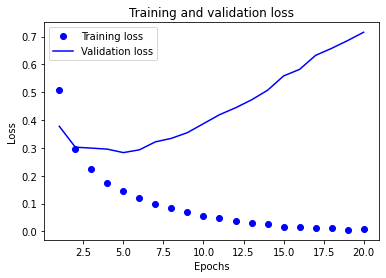

In [ ]:
import matplotlib.pyplot as plt

acc = history.history['acc']
val_acc = history.history['val_acc']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

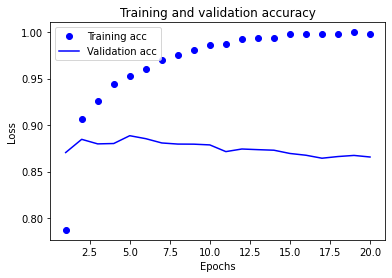

In [ ]:
plt.clf()

plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

epoch = 1

In [ ]:
model = models.Sequential()
model.add(layers.Dense(16, activation='relu', input_shape=(10000,)))
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

model.compile(optimizer='rmsprop',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.fit(x_train_data, y_train_data, epochs=1, batch_size=512)
results = model.evaluate(x_test, y_test)

782/782 [==============================] - 2s 2ms/step - loss: 0.3273 - accuracy: 0.8805


In [ ]:
print("Underfitting")
print("=============================================")
print("Training loss and accuracy: {} and {}".format(loss[0],acc[0]))
print("Test loss and accuracy: {} and {}".format(results[0],results[1]))

Underfitting
Training loss and accuracy: 0.5069108605384827 and 0.7873333096504211
Test loss and accuracy: 0.3273029029369354 and 0.8805199861526489


When underfitting test accuracy is actually better than training accuracy

epoch = 12

In [ ]:
model = models.Sequential()
model.add(layers.Dense(16, activation='relu', input_shape=(10000,)))
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

model.compile(optimizer='rmsprop',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.fit(x_train_data, y_train_data, epochs=12, batch_size=512)
results = model.evaluate(x_test, y_test)

Epoch 1/12
49/49 [==============================] - 1s 12ms/step - loss: 0.5385 - accuracy: 0.7544
Epoch 2/12
49/49 [==============================] - 1s 12ms/step - loss: 0.2668 - accuracy: 0.9120
Epoch 3/12
49/49 [==============================] - 1s 12ms/step - loss: 0.1988 - accuracy: 0.9315
Epoch 4/12
49/49 [==============================] - 1s 12ms/step - loss: 0.1604 - accuracy: 0.9451
Epoch 5/12
49/49 [==============================] - 1s 12ms/step - loss: 0.1391 - accuracy: 0.9537
Epoch 6/12
49/49 [==============================] - 1s 12ms/step - loss: 0.1167 - accuracy: 0.9630
Epoch 7/12
49/49 [==============================] - 1s 12ms/step - loss: 0.1040 - accuracy: 0.9664
Epoch 8/12
49/49 [==============================] - 1s 12ms/step - loss: 0.0923 - accuracy: 0.9690
Epoch 9/12
49/49 [==============================] - 1s 12ms/step - loss: 0.0811 - accuracy: 0.9742
Epoch 10/12
49/49 [==============================] - 1s 12ms/step - loss: 0.0733 - accuracy: 0.9764
Epoch 11/

In [ ]:
print("Overfitting")
print("=============================================")
print("Training loss and accuracy: {} and {}".format(loss[11],acc[11]))
print("Test loss and accuracy: {} and {}".format(results[0],results[1]))

Overfitting
Training loss and accuracy: 0.036342933773994446 and 0.9924666881561279
Test loss and accuracy: 0.5020960569381714 and 0.8593199849128723


When overfitting test accuracy is worse than training accuracy, and by a quite large amount

# Regularization


*   L1: Did help a little after the epochs went up
*   L2: Didn't help very much
*   L1-L2: Didn't help much on accuracy but overfitting is reduced to a certain amount


Epoch 1/15
49/49 [==============================] - 2s 33ms/step - loss: 0.6108 - acc: 0.7218 - val_loss: 0.3812 - val_acc: 0.8774
Epoch 2/15
49/49 [==============================] - 1s 23ms/step - loss: 0.3200 - acc: 0.9060 - val_loss: 0.3181 - val_acc: 0.8896
Epoch 3/15
49/49 [==============================] - 1s 23ms/step - loss: 0.2474 - acc: 0.9237 - val_loss: 0.3071 - val_acc: 0.8899
Epoch 4/15
49/49 [==============================] - 1s 23ms/step - loss: 0.2162 - acc: 0.9375 - val_loss: 0.3135 - val_acc: 0.8885
Epoch 5/15
49/49 [==============================] - 1s 23ms/step - loss: 0.2017 - acc: 0.9397 - val_loss: 0.3221 - val_acc: 0.8850
Epoch 6/15
49/49 [==============================] - 1s 22ms/step - loss: 0.1852 - acc: 0.9483 - val_loss: 0.3556 - val_acc: 0.8738
Epoch 7/15
49/49 [==============================] - 1s 22ms/step - loss: 0.1798 - acc: 0.9524 - val_loss: 0.3448 - val_acc: 0.8788
Epoch 8/15
49/49 [==============================] - 1s 28ms/step - loss: 0.1764 - a

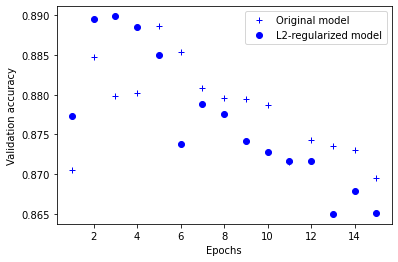

In [ ]:
from keras import regularizers

l2_model = models.Sequential()
l2_model.add(layers.Dense(16, kernel_regularizer=regularizers.l2(0.0005),
                          activation='relu', input_shape=(10000,)))
l2_model.add(layers.Dense(16, kernel_regularizer=regularizers.l2(0.0005),
                          activation='relu'))
l2_model.add(layers.Dense(1, activation='sigmoid'))

l2_model.compile(optimizer='rmsprop',
                 loss='binary_crossentropy',
                 metrics=['acc'])

l2_model_hist = l2_model.fit(x_train_data, y_train_data,
                             epochs=15,
                             batch_size=512,
                             validation_data=(x_test, y_test))

l2_model_val_acc = l2_model_hist.history['val_acc']

plt.plot(epochs[:15], val_acc[:15], 'b+', label='Original model')
plt.plot(epochs[:15], l2_model_val_acc, 'bo', label='L2-regularized model')
plt.xlabel('Epochs')
plt.ylabel('Validation accuracy')
plt.legend()

plt.show()

Epoch 1/15
49/49 [==============================] - 3s 43ms/step - loss: 0.9791 - acc: 0.7196 - val_loss: 0.5434 - val_acc: 0.8623
Epoch 2/15
49/49 [==============================] - 1s 23ms/step - loss: 0.5233 - acc: 0.8670 - val_loss: 0.4864 - val_acc: 0.8753
Epoch 3/15
49/49 [==============================] - 1s 23ms/step - loss: 0.4787 - acc: 0.8729 - val_loss: 0.4660 - val_acc: 0.8756
Epoch 4/15
49/49 [==============================] - 1s 23ms/step - loss: 0.4474 - acc: 0.8861 - val_loss: 0.4585 - val_acc: 0.8763
Epoch 5/15
49/49 [==============================] - 1s 23ms/step - loss: 0.4471 - acc: 0.8815 - val_loss: 0.4531 - val_acc: 0.8762
Epoch 6/15
49/49 [==============================] - 1s 24ms/step - loss: 0.4311 - acc: 0.8877 - val_loss: 0.4545 - val_acc: 0.8742
Epoch 7/15
49/49 [==============================] - 1s 23ms/step - loss: 0.4277 - acc: 0.8851 - val_loss: 0.4466 - val_acc: 0.8760
Epoch 8/15
49/49 [==============================] - 1s 23ms/step - loss: 0.4194 - a

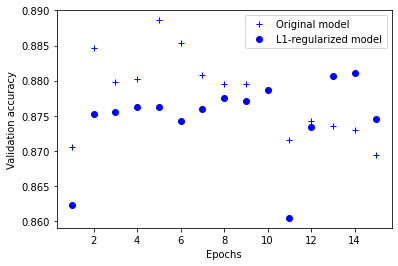

In [ ]:
l1_model = models.Sequential()
l1_model.add(layers.Dense(16, kernel_regularizer=regularizers.l1(0.0005),
                          activation='relu', input_shape=(10000,)))
l1_model.add(layers.Dense(16, kernel_regularizer=regularizers.l1(0.0005),
                          activation='relu'))
l1_model.add(layers.Dense(1, activation='sigmoid'))

l1_model.compile(optimizer='rmsprop',
                 loss='binary_crossentropy',
                 metrics=['acc'])

l1_model_hist = l1_model.fit(x_train_data, y_train_data,
                             epochs=15,
                             batch_size=512,
                             validation_data=(x_test, y_test))

l1_model_val_acc = l1_model_hist.history['val_acc']

plt.plot(epochs[:15], val_acc[:15], 'b+', label='Original model')
plt.plot(epochs[:15], l1_model_val_acc, 'bo', label='L1-regularized model')
plt.xlabel('Epochs')
plt.ylabel('Validation accuracy')
plt.legend()

plt.show()

Epoch 1/15
49/49 [==============================] - 2s 32ms/step - loss: 1.3449 - acc: 0.6653 - val_loss: 0.7196 - val_acc: 0.8072
Epoch 2/15
49/49 [==============================] - 1s 22ms/step - loss: 0.6828 - acc: 0.8297 - val_loss: 0.6322 - val_acc: 0.8431
Epoch 3/15
49/49 [==============================] - 1s 23ms/step - loss: 0.6179 - acc: 0.8491 - val_loss: 0.6016 - val_acc: 0.8497
Epoch 4/15
49/49 [==============================] - 1s 23ms/step - loss: 0.5944 - acc: 0.8516 - val_loss: 0.5879 - val_acc: 0.8512
Epoch 5/15
49/49 [==============================] - 1s 23ms/step - loss: 0.5767 - acc: 0.8571 - val_loss: 0.5710 - val_acc: 0.8562
Epoch 6/15
49/49 [==============================] - 1s 23ms/step - loss: 0.5738 - acc: 0.8530 - val_loss: 0.5567 - val_acc: 0.8599
Epoch 7/15
49/49 [==============================] - 1s 23ms/step - loss: 0.5550 - acc: 0.8595 - val_loss: 0.5497 - val_acc: 0.8628
Epoch 8/15
49/49 [==============================] - 1s 23ms/step - loss: 0.5489 - a

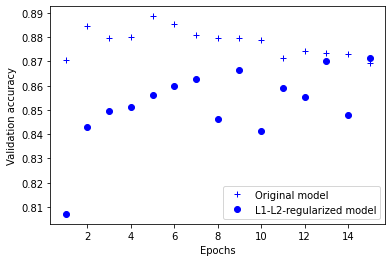

In [ ]:
l1_l2_model = models.Sequential()
l1_l2_model.add(layers.Dense(16, kernel_regularizer=regularizers.l1_l2(l1=0.001, l2=0.001),
                          activation='relu', input_shape=(10000,)))
l1_l2_model.add(layers.Dense(16, kernel_regularizer=regularizers.l1_l2(l1=0.001, l2=0.001),
                          activation='relu'))
l1_l2_model.add(layers.Dense(1, activation='sigmoid'))

l1_l2_model.compile(optimizer='rmsprop',
                 loss='binary_crossentropy',
                 metrics=['acc'])

l1_l2_model_hist = l1_l2_model.fit(x_train_data, y_train_data,
                             epochs=15,
                             batch_size=512,
                             validation_data=(x_test, y_test))

l1_l2_model_val_acc = l1_l2_model_hist.history['val_acc']

plt.plot(epochs[:15], val_acc[:15], 'b+', label='Original model')
plt.plot(epochs[:15], l1_l2_model_val_acc, 'bo', label='L1-L2-regularized model')
plt.xlabel('Epochs')
plt.ylabel('Validation accuracy')
plt.legend()

plt.show()

Dropout: As epochs went up, accuracy is a little higher than training

Epoch 1/20
49/49 [==============================] - 2s 30ms/step - loss: 0.6437 - acc: 0.6264 - val_loss: 0.4854 - val_acc: 0.8596
Epoch 2/20
49/49 [==============================] - 1s 23ms/step - loss: 0.4898 - acc: 0.8067 - val_loss: 0.3907 - val_acc: 0.8794
Epoch 3/20
49/49 [==============================] - 1s 23ms/step - loss: 0.4020 - acc: 0.8596 - val_loss: 0.3353 - val_acc: 0.8845
Epoch 4/20
49/49 [==============================] - 1s 22ms/step - loss: 0.3526 - acc: 0.8807 - val_loss: 0.3104 - val_acc: 0.8809
Epoch 5/20
49/49 [==============================] - 1s 23ms/step - loss: 0.3026 - acc: 0.8997 - val_loss: 0.3018 - val_acc: 0.8852
Epoch 6/20
49/49 [==============================] - 1s 23ms/step - loss: 0.2716 - acc: 0.9097 - val_loss: 0.3016 - val_acc: 0.8848
Epoch 7/20
49/49 [==============================] - 1s 22ms/step - loss: 0.2403 - acc: 0.9226 - val_loss: 0.3030 - val_acc: 0.8798
Epoch 8/20
49/49 [==============================] - 1s 22ms/step - loss: 0.2233 - a

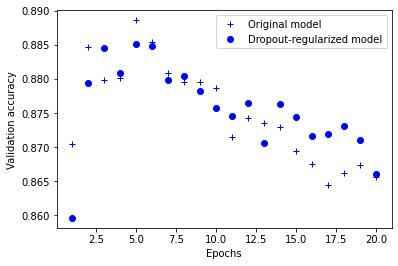

In [ ]:
dpt_model = models.Sequential()
dpt_model.add(layers.Dense(16, activation='relu', input_shape=(10000,)))
dpt_model.add(layers.Dropout(0.5))
dpt_model.add(layers.Dense(16, activation='relu'))
dpt_model.add(layers.Dropout(0.5))
dpt_model.add(layers.Dense(1, activation='sigmoid'))

dpt_model.compile(optimizer='rmsprop',
                  loss='binary_crossentropy',
                  metrics=['acc'])

dpt_model_hist = dpt_model.fit(x_train_data, y_train_data,
                               epochs=20,
                               batch_size=512,
                               validation_data=(x_test, y_test))

dpt_model_val_acc = dpt_model_hist.history['val_acc']

plt.plot(epochs, val_acc, 'b+', label='Original model')
plt.plot(epochs, dpt_model_val_acc, 'bo', label='Dropout-regularized model')
plt.xlabel('Epochs')
plt.ylabel('Validation accuracy')
plt.legend()

plt.show()